In [1]:
import pandas as pd
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
import ast

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
luis_datapath = '/content/drive/MyDrive/Cardiff/Grants/NERD: Neutralizing Economic Rewards of Disinformation/Result_artifacts/Articles_Data_Archive/combined_articles_dataset.csv'
datapath_niraj_articles = '/content/drive/MyDrive/NERD: Neutralizing Economic Rewards of Disinformation/Result_artifacts/Articles_Data_Archive/combined_articles_dataset.csv'
article_df = pd.read_csv(datapath_niraj_articles)

## Analyzing Text Length for Headlines and Articles

The following code snippet performs exploratory analysis on the length of headlines and articles in a dataset. The goal is to calculate the text lengths for the `Headline` and `Article_Text` columns, then generate and print summary statistics to understand the data distribution.



In [4]:
# Convert 'Headline' column to string and calculate the length of each headline,
# storing the results in a new column 'headline_length'
article_df['headline_length'] = article_df['Headline'].astype(str).apply(len)

# Convert 'Article_Text' column to string and calculate the length of each article,
# storing the results in a new column 'article_length'
article_df['article_length'] = article_df['Article_Text'].astype(str).apply(len)

# Generate summary statistics for headline lengths (e.g., mean, min, max, etc.)
headline_stats = article_df['headline_length'].describe()

# Generate summary statistics for article lengths (e.g., mean, min, max, etc.)
article_stats = article_df['article_length'].describe()

# Print the summary statistics for headline lengths
print(headline_stats)

# Print the summary statistics for article lengths
print(article_stats)

count    176.000000
mean      75.278409
std       28.123743
min        9.000000
25%       59.000000
50%       74.500000
75%       92.000000
max      198.000000
Name: headline_length, dtype: float64
count     176.000000
mean      404.556818
std       383.768051
min         3.000000
25%       170.250000
50%       290.000000
75%       519.500000
max      2458.000000
Name: article_length, dtype: float64


## Visualizing the Distribution of Article Lengths

The following code snippet creates a histogram to visualize the distribution of article lengths in the dataset. This provides a clear understanding of the frequency of articles with varying lengths.


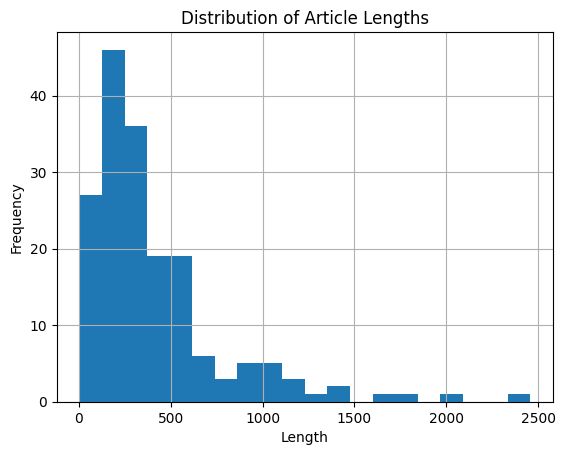

In [5]:
# Create a histogram of the 'article_length' column with 20 bins to show the distribution
article_df['article_length'].hist(bins=20)
plt.title('Distribution of Article Lengths')
plt.xlabel('Length')
plt.ylabel('Frequency')
plt.savefig('distribution_of_article_lenghts.png')
plt.show()

## Analyzing Articles Published Per Month

This code snippet filters the dataset for valid publication dates, processes the dates, and visualizes the number of articles published each month as a bar chart.



<ipython-input-6-be50b80af247>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  article_date['Published_Date'] = pd.to_datetime(article_date['Published_Date'], format='%d-%m-%Y', errors='coerce')


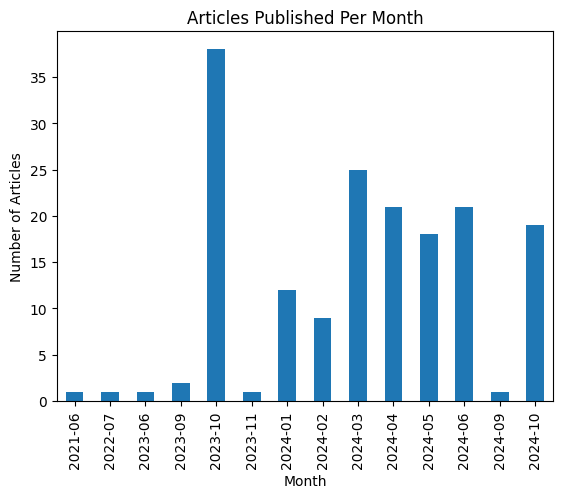

In [6]:
# Filter the DataFrame for valid publication dates
article_date = article_df[(article_df['Published_Date'] != 'Not Found') & (~article_df['Published_Date'].isnull())]

# Convert the 'Published_Date' column to datetime with error handling
article_date['Published_Date'] = pd.to_datetime(article_date['Published_Date'], format='%d-%m-%Y', errors='coerce')

# Drop rows with NaT after conversion
article_date = article_date.dropna(subset=['Published_Date'])

# Group by month and count the number of articles published per month
article_date['Published_Date'].groupby(article_date['Published_Date'].dt.to_period("M")).count().plot(kind='bar')

# Set the plot title and labels
plt.title('Articles Published Per Month')
plt.xlabel('Month')
plt.ylabel('Number of Articles')
plt.savefig('articles_published_per_month.png')
# Show the plot
plt.show()

## Identifying Top Publishing Agencies

This code snippet identifies the top 10 publishing agencies based on the number of articles they have published in the dataset.



In [7]:
# Top publishing agencies
top_agencies = article_df['Publishing_Agency_Name'].value_counts().head(10)
top_agencies

,count
Publishing_Agency_Name,
Informer,13
PRONEWS,11
Slobodna Bosna,4
Pamfleti,4
Público,4
Milliyet,4
N1 Hrvatska,4
New York Post,4
Asia Times,4


## Identifying Top Publishing Agencies

This code snippet identifies the top 10 publishing agencies based on the number of articles they have published in the dataset.



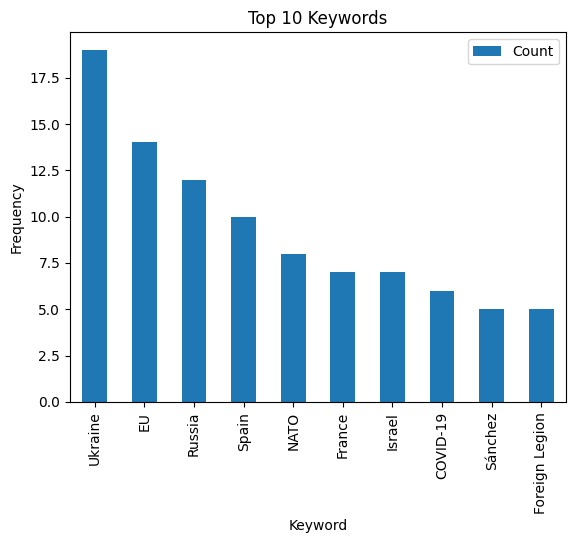

In [8]:
# Convert the string representation of the 'Keywords_Tags' list into an actual list object
# for each entry in the 'Keywords_Tags' column
article_df['Keywords_Tags'] = article_df['Keywords_Tags'].apply(ast.literal_eval)
keywords = article_df[~article_df['Keywords_Tags'].apply(lambda x: 'Not Found' in x)]
keywords = keywords[keywords['Keywords_Tags'].apply(lambda x: x != [])]
all_keywords = [keyword for sublist in article_df['Keywords_Tags'] for keyword in sublist]

keyword_counts = Counter(all_keywords)

# Get the top 10 most common keywords along with their counts
top_keywords = keyword_counts.most_common(10)


keywords_df = pd.DataFrame(top_keywords, columns=['Keyword', 'Count'])
keywords_df.plot(kind='bar', x='Keyword', y='Count')
plt.title('Top 10 Keywords')
plt.xlabel('Keyword')
plt.ylabel('Frequency')
plt.savefig('Top_10_keywords.png')
plt.show()

## Analyzing Sentiment Statistics

This code snippet filters the dataset to analyze the sentiment of articles and visualizes its distribution using a histogram.


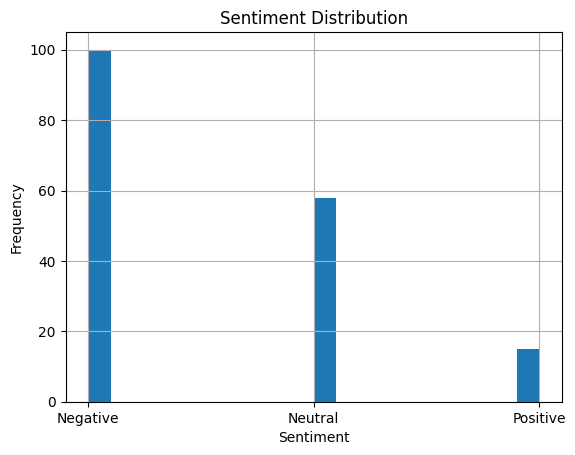

In [9]:
# Sentiment statistics
sentiment  =  article_df[article_df['Sentiment']!= 'Not Found']
sentiment = sentiment['Sentiment'].dropna()

# Sentiment distribution
sentiment.hist(bins=20)
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Frequency')
plt.savefig('Sentiment_distribution.png')
plt.show()

## Analyzing Tone Distribution

This code snippet analyzes the tone of articles in the dataset and visualizes the distribution as a bar chart.


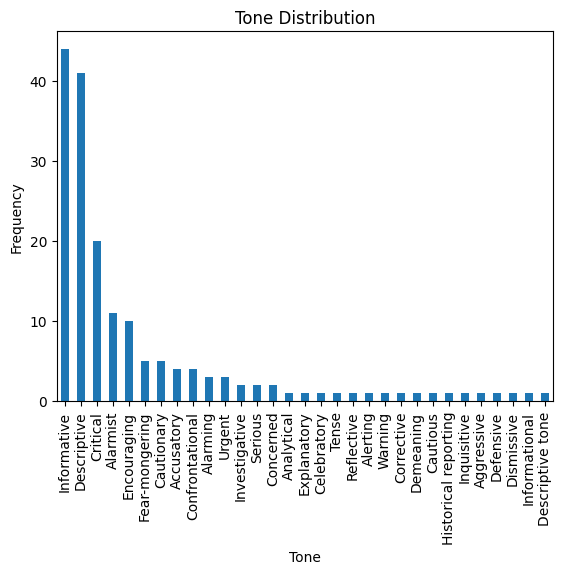

In [10]:
tone  = article_df[article_df['Tone']!= 'Not Found']
tone = tone['Tone'].dropna()

tone_distribution = tone.value_counts()
tone_distribution.plot(kind='bar')
plt.title('Tone Distribution')
plt.xlabel('Tone')
plt.ylabel('Frequency')
plt.savefig('tone_distribution.png')
plt.show()

# Luis

In [ ]:
article_df

## Most frequent keywords

In [ ]:
from collections import defaultdict,Counter
d = defaultdict(int)
for idx,row in article_df.iterrows():
  kws = row.Keywords_Tags
  for kw in kws:
    d[kw] += 1

In [ ]:
Counter(d).most_common(20)

## Visualize frequent keywords

In [ ]:
import numpy as np
import pandas as pd
from sklearn.manifold import TSNE
import plotly.express as px
from sentence_transformers import SentenceTransformer
from collections import Counter

def process_keywords_and_visualize(article_df):
    # Extract all unique keywords and count their frequencies
    all_keywords = []
    for keywords in article_df['Keywords_Tags']:
        all_keywords.extend(keywords)

    # Count frequencies
    keyword_counts = Counter(all_keywords)
    unique_keywords = list(keyword_counts.keys())

    # Generate embeddings
    model = SentenceTransformer('all-MiniLM-L6-v2')
    embeddings = model.encode(unique_keywords, show_progress_bar=True)

    # Perform t-SNE
    tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(unique_keywords)-1))
    tsne_results = tsne.fit_transform(embeddings)

    # Create a DataFrame for plotting
    plot_df = pd.DataFrame({
        'x': tsne_results[:, 0],
        'y': tsne_results[:, 1],
        'keyword': unique_keywords,
        'frequency': [keyword_counts[k] for k in unique_keywords]
    })

    # Create interactive scatter plot
    fig = px.scatter(
        plot_df,
        x='x',
        y='y',
        size='frequency',  # Size of points based on frequency
        color='frequency',  # Color gradient based on frequency
        hover_data={
            'x': False,  # Hide x coordinate in hover
            'y': False,  # Hide y coordinate in hover
            'keyword': True,
            'frequency': True
        },
        labels={
            'frequency': 'Keyword Frequency'
        },
        title='Keyword Embedding Visualization'
    )

    # Update layout for better visualization
    fig.update_traces(
        marker=dict(
            sizeref=2.*max(plot_df['frequency'])/(40.**2),  # Adjust size scaling
            sizemin=4  # Minimum size for points
        )
    )

    # Update layout
    fig.update_layout(
        width=1000,
        height=800,
        showlegend=True,
        xaxis_title="t-SNE dimension 1",
        yaxis_title="t-SNE dimension 2",
        xaxis=dict(showgrid=False),
        yaxis=dict(showgrid=False)
    )

    # Add text annotations for top keywords
    top_n = 20  # Number of keywords to label
    top_keywords = plot_df.nlargest(top_n, 'frequency')

    annotations = []
    for _, row in top_keywords.iterrows():
        annotations.append(
            dict(
                x=row['x'],
                y=row['y'],
                text=row['keyword'],
                showarrow=True,
                arrowhead=0,
                ax=20,
                ay=-20,
                font=dict(size=10)
            )
        )

    fig.update_layout(annotations=annotations)

    return fig

/usr/local/lib/python3.10/dist-packages/sentence_transformers/cross_encoder/CrossEncoder.py:13: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm, trange


In [ ]:
# Example usage:
fig = process_keywords_and_visualize(article_df)

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.7k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

1_Pooling/config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/16 [00:00<?, ?it/s]

In [ ]:
fig.show()  # Display in notebook

In [ ]:
fig.write_html("keyword_visualization.html")  # Save as interactive HTML file